# Análisis de segmentación de clientes e información empresarial

## Preguntas clave

### 1. ¿Cómo se distribuyen los clientes en los segmentos identificados?

- ¿Cuántos clientes pertenecen a cada segmento?
- ¿Qué porcentaje de la base de clientes representa cada segmento?
- ¿Los segmentos están equilibrados o muy concentrados?

### 2. ¿Cuáles son las principales características de cada segmento de clientes?

- ¿En qué se diferencia Recency entre segmentos?
- ¿En qué se diferencia la frecuencia entre segmentos?
- ¿En qué se diferencia el valor monetario entre segmentos?
- ¿En qué se diferencian el valor medio del pedido y la cantidad media entre segmentos?
- ¿En qué se diferencia el comportamiento de los descuentos entre segmentos?

### 3. ¿Qué segmentos de clientes generan más ingresos?

- ¿Qué segmento aporta la mayor cantidad de ingresos totales?
- ¿El segmento con más clientes también genera más ingresos?
- ¿Qué tan concentrados están los ingresos de la empresa en los diferentes segmentos?

### 4. ¿Qué segmentos representan las mayores oportunidades de negocio?

- ¿A qué clientes se debe dar prioridad para la retención?
- ¿A qué clientes debería apuntarse la reactivación?
- ¿Qué clientes tienen el mayor potencial de ventas adicionales o cruzadas?
- ¿Qué segmentos podrían generar el mayor impacto financiero?

### 5. ¿Cuál es el impacto financiero potencial de estas estrategias?

- ¿Cuántos ingresos podrían retenerse o recuperarse?
- ¿Qué segmento ofrece el mayor potencial de retorno de acciones específicas?
- ¿Qué KPI se deben monitorear para medir el éxito de cada estrategia?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.style.use("ggplot")
sns.set_theme(style="darkgrid")

customers = pd.read_csv("../../data/processed/customers_with_clusters.csv")
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 4335 entries, 0 to 4334
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      4335 non-null   int64  
 1   recency          4335 non-null   int64  
 2   frequency        4335 non-null   int64  
 3   monetary         4335 non-null   float64
 4   avg_order_value  4335 non-null   float64
 5   avg_quantity     4335 non-null   float64
 6   discount_rate    4335 non-null   float64
 7   cluster_name     4335 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 271.1 KB


## 1. Distribución del segmento de clientes

Analizaremos la distribución de clientes en los segmentos identificados para comprender cuántos clientes pertenecen a cada segmento, qué porcentaje de la base de clientes representa cada segmento y si los segmentos están equilibrados o altamente concentrados.

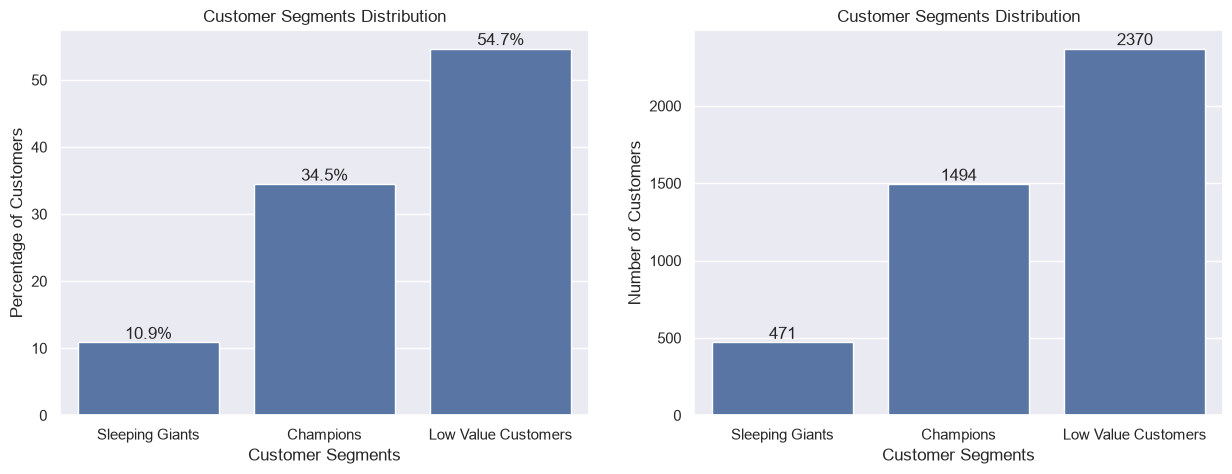

In [2]:
fig , axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(x="cluster_name", data=customers , stat="percent" , ax=axes[0])
axes[0].set_title("Customer Segments Distribution")
axes[0].set_xlabel("Customer Segments")
axes[0].set_ylabel("Percentage of Customers")

axes[0].bar_label(axes[0].containers[0], labels=[f"{(p.get_height()):.1f}%" for p in axes[0].patches], label_type='edge')


sns.countplot(x="cluster_name",  data=customers , ax=axes[1])
axes[1].set_title("Customer Segments Distribution")
axes[1].set_xlabel("Customer Segments")
axes[1].set_ylabel("Number of Customers")

axes[1].bar_label(axes[1].containers[0], labels=[f"{int(p.get_height())}" for p in axes[1].patches], label_type='edge')

plt.show()


## Resumen

- **Clientes de bajo valor (2370 / 54,7%)**: esto sugiere que una parte importante de la base de clientes no contribuye sustancialmente a los ingresos, lo que indica la necesidad de estrategias de marketing o participación dirigidas para aumentar su valor.

- **Campeones (1494 / 34,5%)**: esto indica una gran oportunidad para retener y nutrir a estos clientes de alto valor, ya que es probable que sean leales y generen ingresos constantes.

- **Gigantes durmientes (471 / 10,9%)**: este tiende a ser un segmento más pequeño, pero representa una oportunidad de crecimiento potencial si se puede volver a involucrar a estos clientes y convertirlos en compradores más activos.

La distribución de clientes entre segmentos resalta la importancia de centrarse tanto en retener clientes de alto valor como en encontrar formas de aumentar el valor de los segmentos de menor valor.

Por lo tanto, podemos concluir que, aunque los segmentos no están **perfectamente equilibrados**, proporcionan una visión integral de la base de clientes y pueden guiar la toma de decisiones estratégicas.

## 2. Análisis del perfil del segmento

Analizaremos las diferencias entre segmentos y entenderemos las principales características de cada uno.

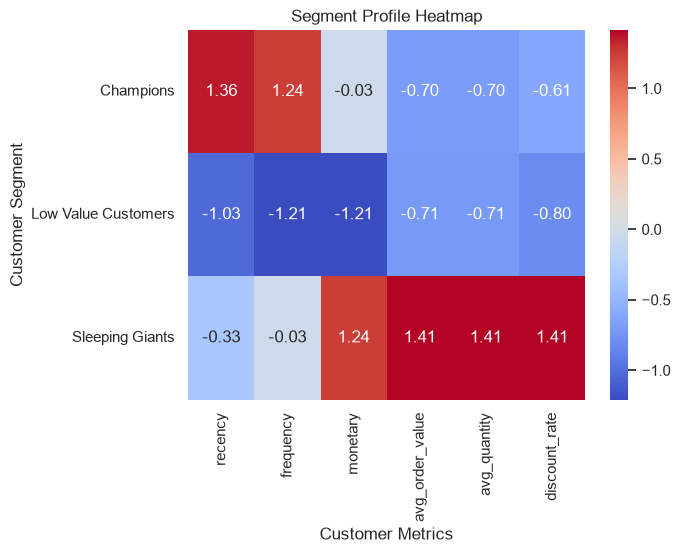

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

segment_profile = customers.groupby("cluster_name")[
    [
        "recency",
        "frequency",
        "monetary",
        "avg_order_value",
        "avg_quantity",
        "discount_rate"
    ]
].mean()

segment_profile_scaled = pd.DataFrame(
    scaler.fit_transform(segment_profile),
    index=segment_profile.index,
    columns=segment_profile.columns
)

segment_profile_scaled["recency"] *= -1


sns.heatmap(segment_profile_scaled, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Segment Profile Heatmap")
plt.xlabel("Customer Metrics")
plt.ylabel("Customer Segment")

plt.show()

## Resumen

Con este mapa de calor, podemos observar los siguientes conocimientos sobre cada segmento de clientes:


- **Campeones**: muestra el perfil de cliente general más sólido, con alta frecuencia, valor monetario, valor promedio de pedido y cantidad, combinado con compras muy recientes.
- **Clientes de bajo valor**: exhiben el perfil general de cliente más débil, con baja frecuencia, valor monetario, valor promedio de pedido y cantidad, combinado con compras menos recientes.
- **Gigantes Durmientes**: muestran un perfil mixto, con baja frecuencia y alto valor monetario, pero compras menos recientes, lo que indica potencial de reactivación.

Necesitamos realizar un análisis de la canasta de mercado para comprender las preferencias de productos de cada segmento e identificar oportunidades de ventas cruzadas y adicionales.

## 3. Contribución a los ingresos por segmento

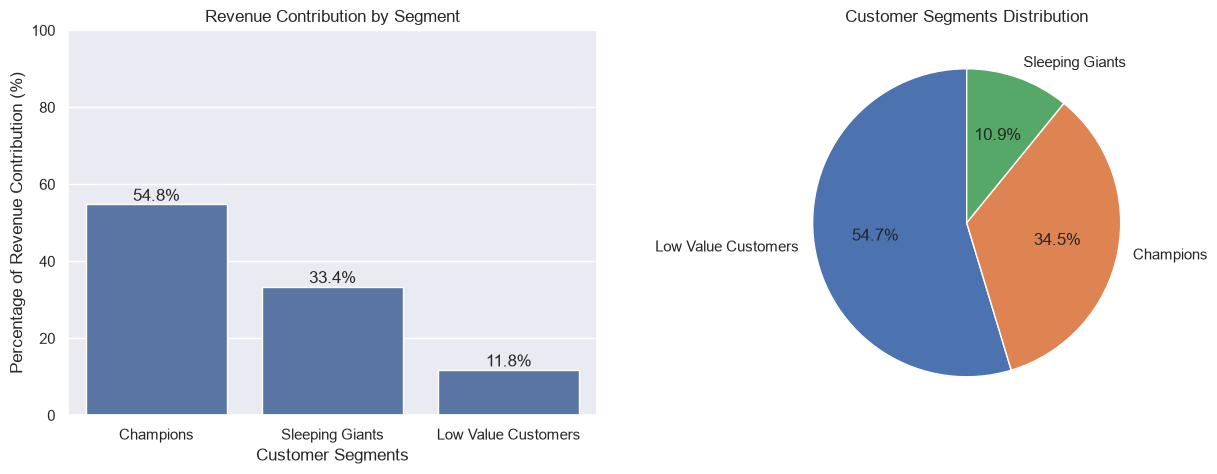

In [4]:
fig , axes = plt.subplots(1,2, figsize=(15,5))

percentage_revenue =  (customers.groupby("cluster_name")["monetary"].sum() / customers["monetary"].sum() * 100).sort_values(ascending=False)
percentage_count = customers.value_counts("cluster_name", normalize=True).sort_values(ascending=False) * 100

sns.barplot(x=percentage_revenue.index, y=percentage_revenue.values , order=percentage_revenue.index , ax=axes[0])
axes[0].set_title("Revenue Contribution by Segment")
axes[0].set_xlabel("Customer Segments")
axes[0].set_ylabel("Percentage of Revenue Contribution (%)")
axes[0].set_ylim(0, 100)

axes[0].bar_label(axes[0].containers[0], labels=[f"{p.get_height():.1f}%" for p in axes[0].patches], label_type='edge')

plt.pie(percentage_count.values, labels=percentage_count.index, autopct='%1.1f%%', startangle=90)
plt.title("Customer Segments Distribution")


plt.show()

## Resumen

El análisis de la contribución a los ingresos por segmento revela los siguientes conocimientos:

- **Champions(54,8%)**: este segmento es el que más contribuye a los ingresos de la empresa, lo que indica que estos clientes son muy valiosos y se les debe dar prioridad en los programas de retención y fidelización. Y son sólo el 34,5% de la base total de clientes, lo que significa que están generando una cantidad desproporcionada de ingresos en comparación con su tamaño.

- **Gigantes durmientes (33,4%)**: este segmento aporta una parte importante de los ingresos, lo que sugiere que volver a atraer a estos clientes podría tener un impacto positivo en los ingresos generales. Por otro lado, su tamaño es significativamente menor (10,9% del total de clientes), lo que significa que tienen un alto potencial de crecimiento si logran reactivarse.

- **Clientes de bajo valor (11,8%)**: este segmento es el que menos contribuye a los ingresos, lo que indica que estos clientes pueden requerir esfuerzos de marketing específicos para aumentar su valor o compromiso. Además, son el segmento más grande (54,7% de la base total de clientes), lo que significa que incluso pequeñas mejoras en su compromiso o gasto podrían tener un impacto significativo en los ingresos generales.

En resumen, tenemos que centrarnos en retener y nutrir el segmento de Campeones, al mismo tiempo que exploramos estrategias para volver a involucrar a los Gigantes Durmientes y aumentar el valor de los Clientes de Bajo Valor.

## 4. Oportunidades de negocio

¿Quiénes son los clientes que representan las mayores oportunidades de negocio? Analicemos el potencial de retención, reactivación y ventas adicionales en los diferentes segmentos.

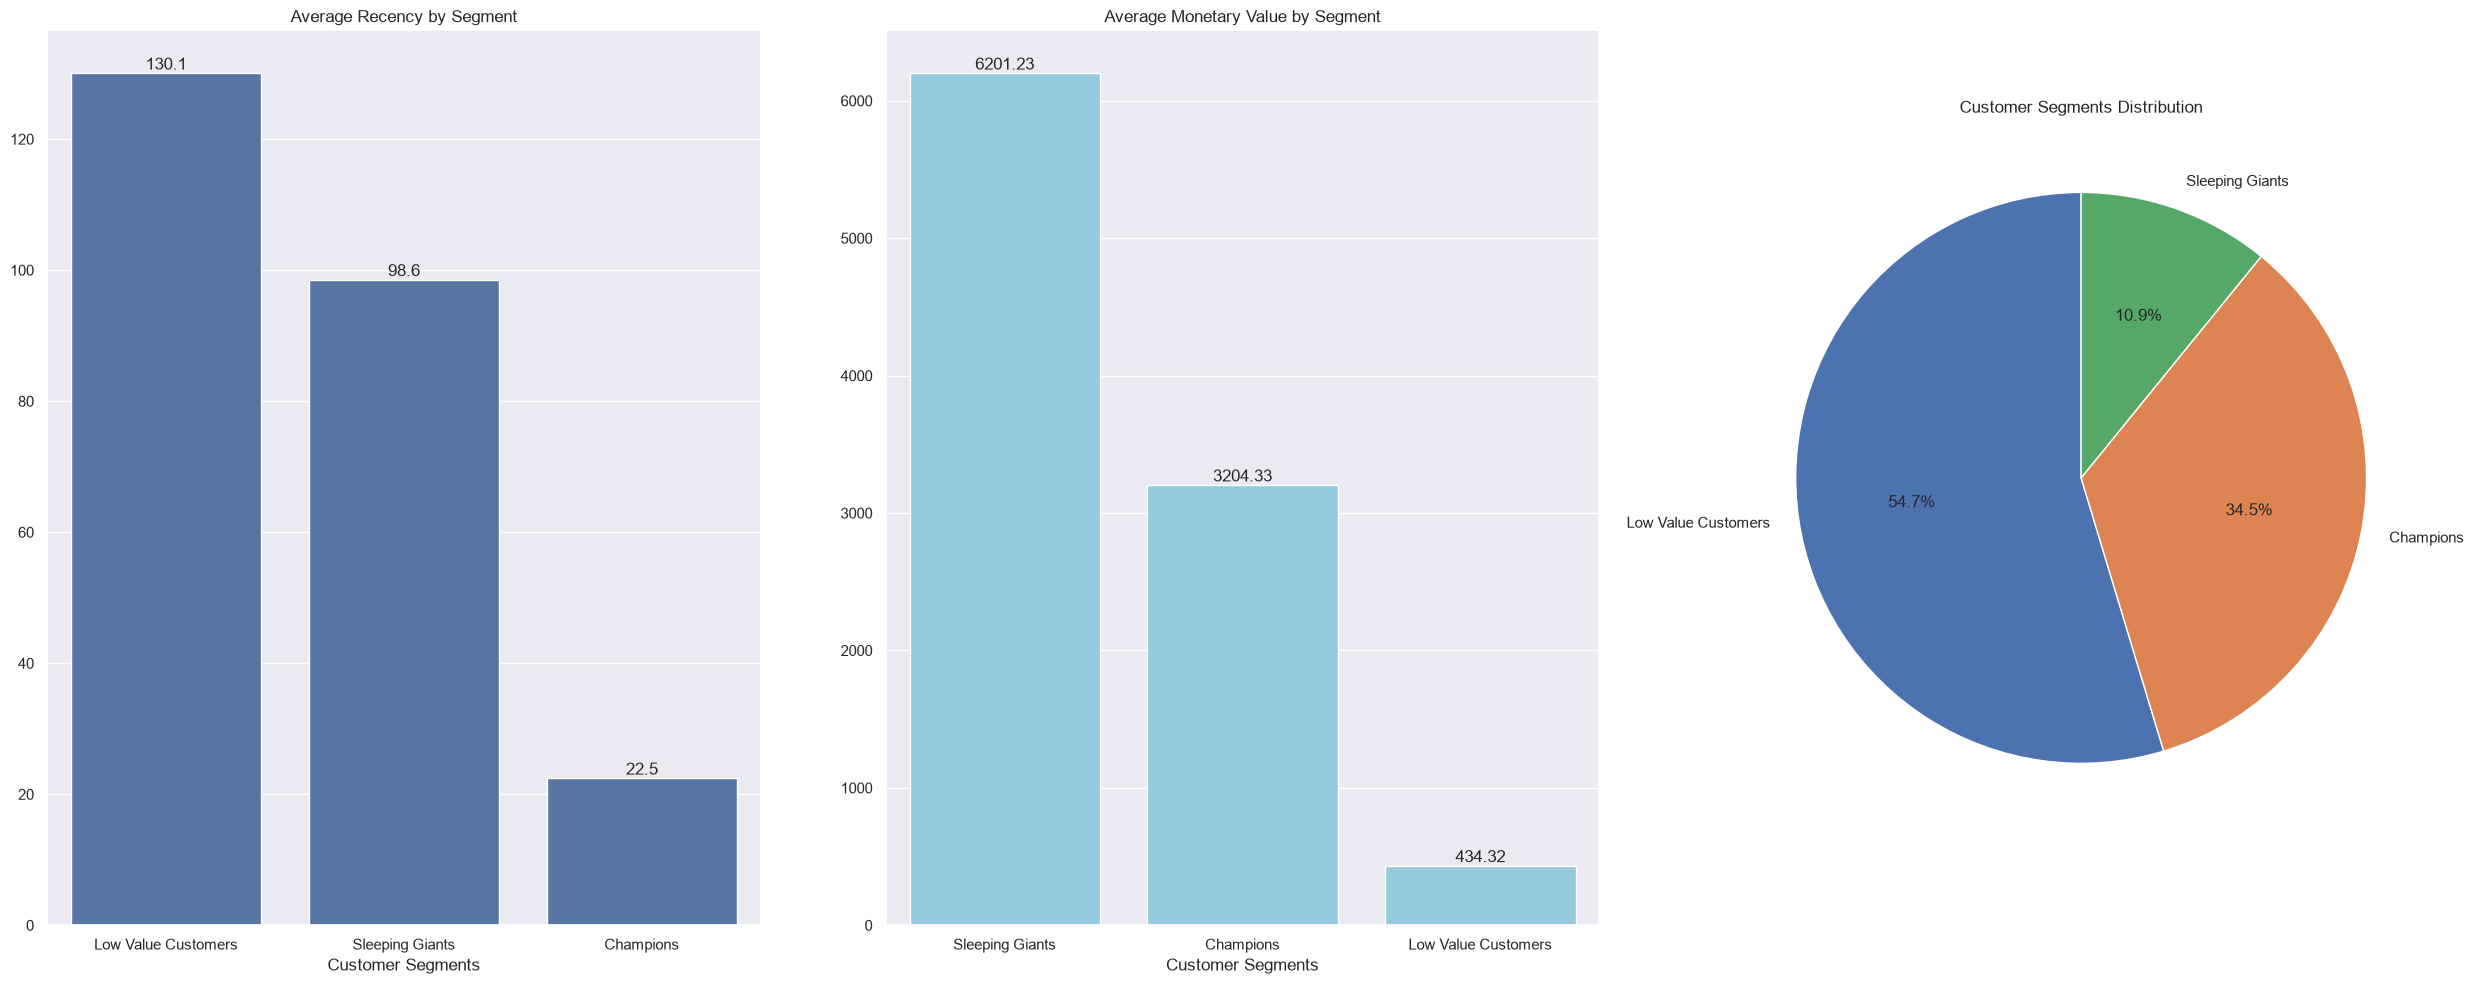

In [22]:
fig , axes = plt.subplots(1,3, figsize=(25,10))

avg_recency_per_segment = customers.groupby("cluster_name")["recency"].mean().sort_values(ascending=False)
sns.barplot(x=avg_recency_per_segment.index, y=avg_recency_per_segment.values , order=avg_recency_per_segment.index , ax=axes[0])
axes[0].set_title("Average Recency by Segment")
axes[0].set_xlabel("Customer Segments")
axes[0].bar_label(axes[0].containers[0], labels=[f"{p.get_height():.1f}" for p in axes[0].patches], label_type='edge')



monetary_per_segment = customers.groupby("cluster_name")["monetary"].mean().sort_values(ascending=False)
sns.barplot(x=monetary_per_segment.index, y=monetary_per_segment.values , order=monetary_per_segment.index , ax=axes[1] , color="skyblue")
axes[1].set_title("Average Monetary Value by Segment")
axes[1].set_xlabel("Customer Segments")
axes[1].bar_label(axes[1].containers[0], labels=[f"{p.get_height():.2f}" for p in axes[1].patches], label_type='edge')

axes[2].pie(percentage_count.values, labels=percentage_count.index, autopct='%1.1f%%', startangle=90)
axes[2].set_title("Customer Segments Distribution")

fig.tight_layout()
plt.show()

## Oportunidades de Negocio

### ¿A qué clientes se debe dar prioridad para la retención?

Los **campeones** deben ser la máxima prioridad para la retención porque están muy comprometidos y generan un valor sustancial para el cliente, con un valor monetario promedio de **3204,33**. Perder estos clientes podría tener un impacto significativo en los ingresos. Las estrategias de retención deben centrarse en programas de fidelización, recomendaciones personalizadas, beneficios exclusivos y un servicio al cliente premium.

Los **Gigantes Durmientes** deberían ser la segunda prioridad porque, a pesar de su menor actividad reciente, tienen el valor monetario promedio más alto con **6.201,23**. Su valor histórico los hace particularmente importantes desde la perspectiva de la protección de los ingresos si pueden volver a involucrarse con éxito.

### ¿A qué clientes debería apuntarse la reactivación?

Los **Gigantes Durmientes** deberían ser el objetivo principal de la reactivación. Su combinación de alto valor monetario histórico y menor actividad reciente representa una importante oportunidad de recuperación de ingresos. Las campañas personalizadas de recuperación, los incentivos específicos y las recomendaciones basadas en compras anteriores podrían animarlos a regresar.

**Los clientes de bajo valor** pueden recibir campañas automatizadas y de menor costo. Dado que su valor monetario promedio es de sólo **434.32**, se debe controlar la inversión en marketing para asegurar que los costos de adquisición o reactivación no superen su valor potencial.

### ¿Qué clientes tienen el mayor potencial para realizar ventas adicionales o cruzadas?

Los **campeones** representan la oportunidad más sólida de ventas adicionales y cruzadas porque ya demuestran un fuerte compromiso y comportamiento de compra, con una antigüedad promedio de aproximadamente **22,5 días**. Su relación existente con la empresa los hace más propensos a responder a productos complementarios, alternativas premium y recomendaciones personalizadas.

Los **Gigantes Durmientes** también son atractivos para aumentar las ventas después de una reactivación exitosa. Su alto valor monetario histórico sugiere que recuperar su participación podría crear oportunidades de ingresos adicionales.

### ¿Qué segmentos podrían generar el mayor impacto financiero?

Los **Champions** representan el segmento más importante para proteger los ingresos existentes debido a su alto compromiso y valor para el cliente. Retener a estos clientes debe tratarse como una estrategia de protección de ingresos.

Los **Gigantes Durmientes** representan el mayor potencial para la recuperación de ingresos. Aunque actualmente son menos activos, su alto valor monetario histórico significa que una reactivación exitosa podría generar ingresos incrementales sustanciales.

Por tanto, la empresa debería utilizar una doble estrategia:

* **Campeones → Proteger los ingresos**
* **Gigantes Durmientes → Recuperar ingresos**
* **Clientes de bajo valor → Interactúe de manera eficiente**

## 6. Impacto financiero

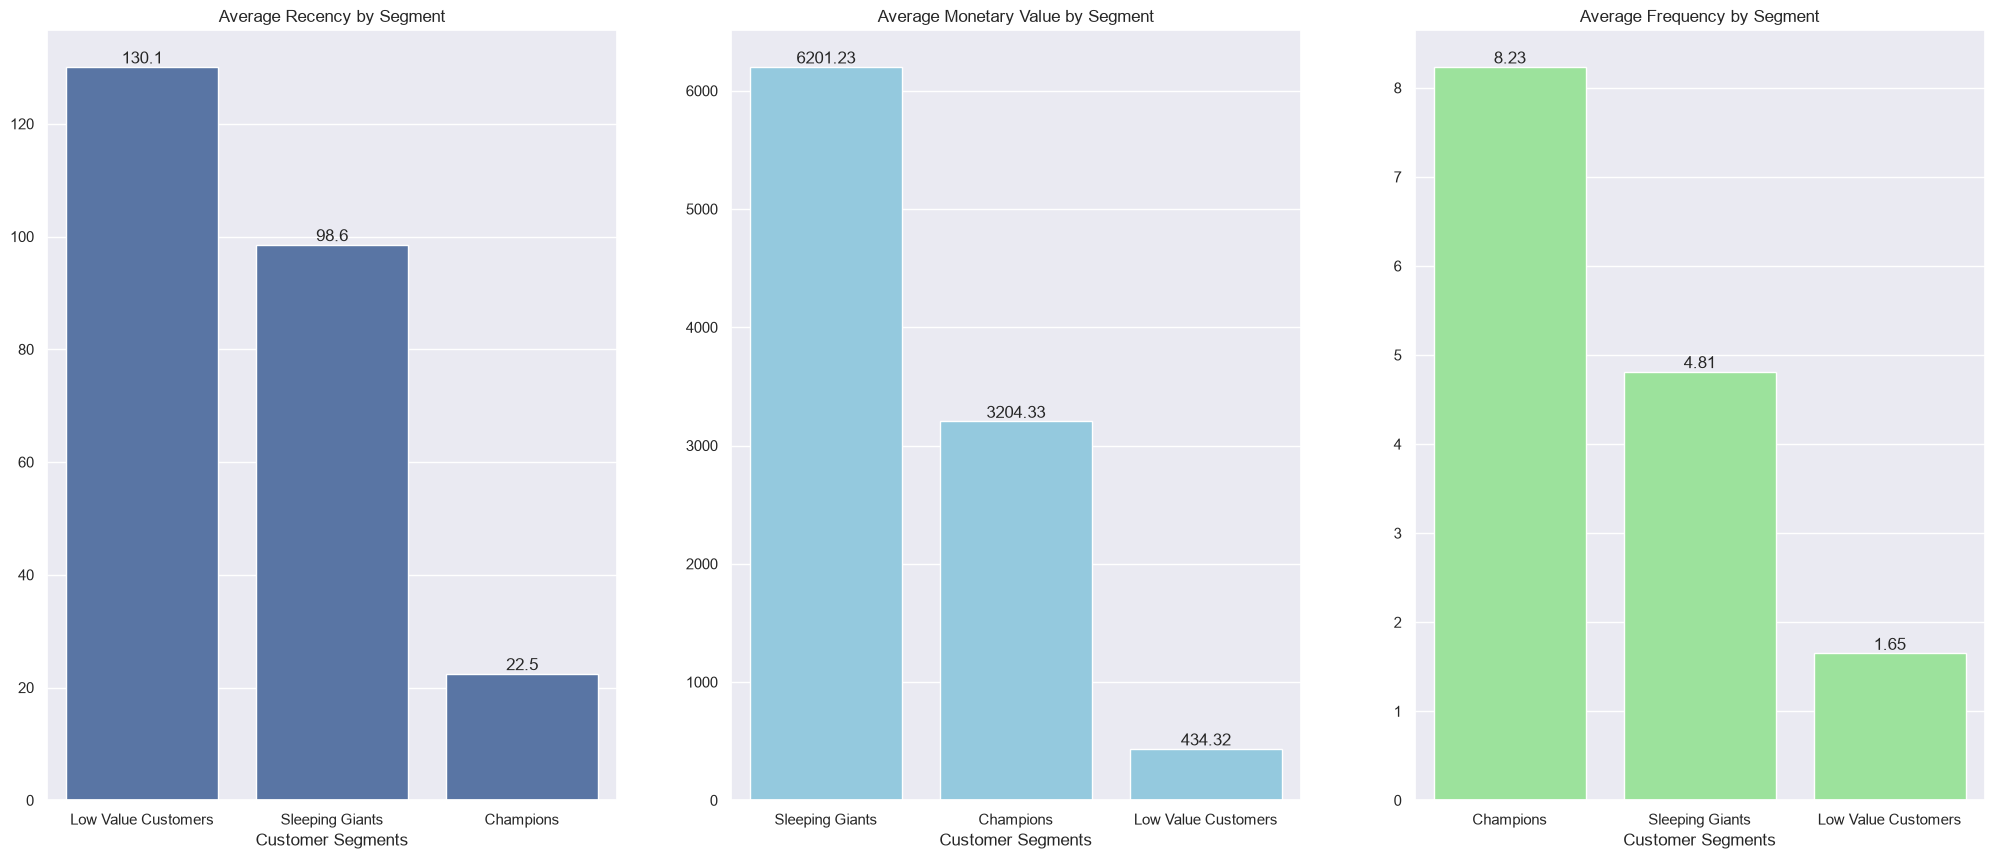

In [23]:
fig , axes = plt.subplots(1,3, figsize=(25,10))

avg_recency_per_segment = customers.groupby("cluster_name")["recency"].mean().sort_values(ascending=False)
sns.barplot(x=avg_recency_per_segment.index, y=avg_recency_per_segment.values , order=avg_recency_per_segment.index , ax=axes[0])
axes[0].set_title("Average Recency by Segment")
axes[0].set_xlabel("Customer Segments")
axes[0].bar_label(axes[0].containers[0], labels=[f"{p.get_height():.1f}" for p in axes[0].patches], label_type='edge')



monetary_per_segment = customers.groupby("cluster_name")["monetary"].mean().sort_values(ascending=False)
sns.barplot(x=monetary_per_segment.index, y=monetary_per_segment.values , order=monetary_per_segment.index , ax=axes[1] , color="skyblue")
axes[1].set_title("Average Monetary Value by Segment")
axes[1].set_xlabel("Customer Segments")
axes[1].bar_label(axes[1].containers[0], labels=[f"{p.get_height():.2f}" for p in axes[1].patches], label_type='edge')

avg_frequency_per_segment = customers.groupby("cluster_name")["frequency"].mean().sort_values(ascending=False)
sns.barplot(x=avg_frequency_per_segment.index, y=avg_frequency_per_segment.values , order=avg_frequency_per_segment.index , ax=axes[2] , color="lightgreen")
axes[2].set_title("Average Frequency by Segment")
axes[2].set_xlabel("Customer Segments")
axes[2].bar_label(axes[2].containers[0], labels=[f"{p.get_height():.2f}" for p in axes[2].patches], label_type='edge')

plt.show()

In [24]:
segment_financial = (
    customers.groupby("cluster_name")
    .agg(
        customers=("customer_id", "count"),
        total_monetary=("monetary", "sum"),
        avg_monetary=("monetary", "mean")
    )
    .sort_values("total_monetary", ascending=False)
)

segment_financial

,customers,total_monetary,avg_monetary
cluster_name,,,
Champions,1494,4787265.60,3204.327711
Sleeping Giants,471,2920778.63,6201.228514
Low Value Customers,2370,1029348.41,434.324224


Crearemos un análisis de impacto financiero con posibles escenarios de recuperación de ingresos basados ​​en diferentes tasas de reactivación para el segmento de Gigantes Durmientes. Esto nos ayudará a comprender el impacto financiero potencial de los esfuerzos de marketing dirigidos y las estrategias de participación del cliente.

- Vamos a utilizar las siguientes tasas de reactivación: 5%, 10%, 15%, 20%, 25% y 30%. Estas tasas representan el porcentaje de Gigantes Durmientes que podrían reactivarse con éxito mediante campañas de marketing específicas y estrategias de participación.

Esto sugiere utilizar la fórmula:

$$
\text{Posible recuperación de ingresos}
=
\text{Ingresos de los gigantes durmientes}
\veces
\text{Tasa de reactivación}
$$

In [33]:
sleeping_giants = segment_financial.loc["Sleeping Giants", "total_monetary"]

scenarios = pd.DataFrame({
    "Reactivation Rate": [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
})

scenarios["Potential Revenue Recovery"] = (
    sleeping_giants * scenarios["Reactivation Rate"]
)

scenarios

,Reactivation Rate,Potential Revenue Recovery
0,0.05,146038.9315
1,0.10,292077.8630
2,0.15,438116.7945
3,0.20,584155.7260
4,0.25,730194.6575
5,0.30,876233.5890


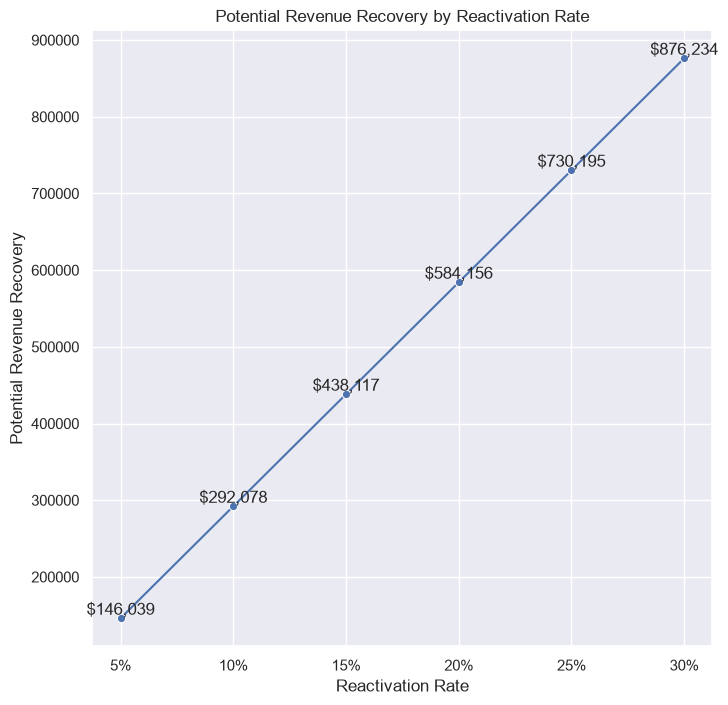

In [34]:
rates = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

plt.figure(figsize=(8, 8))

ax = sns.lineplot(
    data=scenarios,
    x="Reactivation Rate",
    y="Potential Revenue Recovery",
    marker="o"
)

for x, y in zip(
    scenarios["Reactivation Rate"],
    scenarios["Potential Revenue Recovery"]
):
    ax.text(
        x,
        y,
        f"${y:,.0f}",
        ha="center",
        va="bottom"
    )

plt.title("Potential Revenue Recovery by Reactivation Rate")
plt.xlabel("Reactivation Rate")
plt.ylabel("Potential Revenue Recovery")

plt.xticks(
    rates,
    [f"{rate:.0%}" for rate in rates]
)

plt.show()

Utilizamos análisis de escenarios para estimar la recuperación potencial de ingresos asociada con diferentes tasas de reactivación de clientes. El análisis evalúa tasas de reactivación que van del 5% al ​​30%, lo que nos permite cuantificar el impacto financiero potencial de volver a involucrar a los Gigantes Durmientes.

- **5% (Conservador):** Representa un escenario de reactivación cauteloso en el que solo una pequeña proporción de los Gigantes Durmientes regresa. Aunque la recuperación potencial de los ingresos es relativamente limitada, proporciona un punto de referencia de bajo riesgo para evaluar el impacto de los esfuerzos de marketing dirigidos.

- **10% (Moderado):** Representa un escenario base razonable en el que una mayor proporción de Gigantes Durmientes se reactivan con éxito. Este escenario proporciona una estimación equilibrada de la recuperación potencial de los ingresos y puede servir como punto de referencia para el análisis del impacto financiero.

- **15% (agresivo):** Representa un escenario de reactivación más fuerte, suponiendo que las campañas de marketing vuelvan a atraer con éxito a una proporción significativa de los Gigantes Durmientes.
- **20% (Muy Agresivo):** Representa un escenario de reactivación altamente exitoso, que resulta en un aumento sustancial en la recuperación potencial de ingresos.

- **25% (Extremadamente agresivo):** Representa un escenario de reactivación muy ambicioso en el que una gran proporción de Gigantes Durmientes se vuelven a involucrar con éxito.

- **30%:** Representa el escenario de reactivación más alto evaluado en este análisis e ilustra el rango superior de recuperación potencial de ingresos considerado.

En general, el análisis destaca una oportunidad importante para generar ingresos adicionales a través de estrategias de reactivación específicas. El impacto financiero aumenta proporcionalmente con la tasa de reactivación, lo que demuestra el valor potencial de centrar los esfuerzos de marketing en Sleeping Giants.

El escenario Moderado (10%) se utiliza como base para el análisis de impacto financiero, ya que proporciona un punto de referencia razonable entre supuestos conservadores y más agresivos. En este escenario, la recuperación potencial de ingresos estimada es de **$292 078**, lo que representa una oportunidad significativa para recuperar ingresos de clientes previamente activos.

### ¿Qué KPI se deben monitorear para medir el éxito de cada estrategia? :
En este proyecto monitorearemos los siguientes KPI para medir el éxito de cada estrategia:

- Tasa de reactivación: el porcentaje de clientes de Sleeping Giants y Low Value que vuelven a interactuar con éxito a través de campañas de marketing específicas y estrategias de participación.

$$
Tasa\ de reactivación = \frac{\text{Número de clientes reactivados}}{\text{Número total de gigantes durmientes y clientes de bajo valor}} \times 100\%
$$

- Ingresos recuperados: los ingresos totales generados por los clientes reactivados, que se pueden rastrear a lo largo del tiempo para evaluar la efectividad de las campañas de reactivación.

- ROI: El retorno de la inversión de las campañas de marketing dirigidas a clientes de Sleeping Giants y Low Value, calculado comparando los ingresos recuperados con los costes de las campañas.

$$
ROI = \frac{\text{Ingresos recuperados} - \text{Costos de campaña de marketing}}{\text{Costos de campaña de marketing}} \times 100\%
$$

En última instancia, podemos comparar la tasa de reactivación con las tasas de reactivación esperadas del análisis de escenarios para determinar si los esfuerzos de marketing están logrando los resultados deseados. Además, el seguimiento de los ingresos recuperados y el ROI proporcionará información sobre el impacto financiero de las estrategias implementadas.

# Ideas finales y conclusión

## Hallazgos clave

* El conjunto de datos final, analizado a nivel de cliente, contiene **4,335 clientes**, agrupados en tres segmentos accionables: **Clientes de Bajo Valor, Campeones y Gigantes Durmientes**.

* **Los Clientes de Bajo Valor** constituyen el segmento más grande, con **2,370 clientes (54.7%)**, pero generan únicamente **11.8% de los ingresos totales**. Su baja frecuencia de compra, menor valor monetario y menor nivel de actividad sugieren una oportunidad para implementar estrategias de desarrollo escalables y de bajo costo.

* **Los Campeones** comprenden **1,494 clientes (34.5%)** y generan **54.8% de los ingresos totales**. Este segmento presenta el mayor nivel de compromiso y actividad de compra, por lo que debe ser una prioridad en estrategias de **retención, fidelización, personalización y ventas adicionales (upselling/cross-selling)**.

* **Los Gigantes Durmientes** representan solo **471 clientes (10.9%)**, pero generan **33.4% de los ingresos totales** y presentan el mayor valor monetario histórico promedio (**$6,201.23 por cliente**). Aunque actualmente muestran una menor actividad reciente, su alto valor histórico los convierte en la principal oportunidad para implementar estrategias de reactivación.

* Los ingresos presentan una fuerte concentración en clientes de alto valor: **Campeones y Gigantes Durmientes representan conjuntamente el 88.2% de los ingresos totales, mientras que representan solo el 45.4% de la base de clientes**. Esto demuestra que el tamaño de un segmento no necesariamente refleja su importancia financiera.

## Acciones comerciales recomendadas

1. **Proteger a los Campeones:** implementar programas de fidelización, beneficios exclusivos, recomendaciones personalizadas y experiencias diferenciadas para mantener su nivel de compromiso y reducir el riesgo de pérdida de clientes de alto valor.

2. **Reactivar a los Gigantes Durmientes:** diseñar campañas personalizadas basadas en el historial de compras, preferencias de productos y comportamiento previo, complementadas con incentivos controlados. Bajo un escenario de reactivación del **10%**, se estima una recuperación potencial de aproximadamente **$292,078** en ingresos.

3. **Desarrollar a los Clientes de Bajo Valor de manera eficiente:** utilizar promociones automatizadas, estrategias de cross-selling y campañas de bajo costo orientadas a incrementar la frecuencia de compra y el valor promedio de los pedidos. La inversión en marketing debe mantenerse proporcional al valor actual de este segmento.

4. **Medir el desempeño de las estrategias:** monitorear indicadores como **tasa de reactivación, tasa de recompra, ingresos recuperados, retención de Campeones, costo de las campañas y ROI** para evaluar el impacto real de cada iniciativa.

## Conclusión final

El análisis demuestra que **el tamaño de un segmento no necesariamente determina su importancia financiera**. Aunque los Clientes de Bajo Valor representan más de la mitad de la base de clientes, generan una proporción relativamente pequeña de los ingresos. En contraste, los Campeones y los Gigantes Durmientes concentran la mayor parte del valor económico de la empresa.

Por ello, la estrategia comercial recomendada debe seguir una lógica de **priorización basada en el valor del cliente**: **proteger a los Campeones, reactivar a los Gigantes Durmientes y desarrollar gradualmente a los Clientes de Bajo Valor**.

El análisis de escenarios también demuestra que la reactivación de clientes históricamente valiosos puede representar una oportunidad financiera significativa. Sin embargo, estos valores deben interpretarse como **estimaciones de recuperación potencial**, ya que se basan en el comportamiento histórico y en tasas de reactivación hipotéticas.

El dashboard de **Power BI** debe comunicar esta priorización mediante KPI de clientes e ingresos, distribución de segmentos, contribución de ingresos, perfiles RFM, análisis a nivel de cliente y escenarios de recuperación potencial. Finalmente, los **Gigantes Durmientes deben considerarse clientes potencialmente inactivos y no clientes perdidos de forma definitiva**. Las estimaciones financieras deberían validarse mediante campañas piloto y experimentos controlados, permitiendo comparar los resultados reales con las proyecciones y optimizar progresivamente la estrategia de marketing.
